# Feature Selection

### In this tutorial, we will select the most relevant features in our data.

In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif

In [2]:
with open('resp_events.pkl', 'rb') as f:
    resp_events = pickle.load(f)

print('N. resp events', len(resp_events))
resp_labels=np.load("resp_labels.npy") 
print('N. resp labels', len(resp_labels))
resp_feat=np.load("resp_feat.npy") 
print('N. features', len(resp_feat[0]))


N. resp events 17414
N. resp labels 17414
N. features 10


## Inspection of the correlated features
### Check which features are highly correlated by looking at the correlation matrix. The statistical relevance to the target variable of each feature is then assessed trough an ANOVA F-test.

In [13]:
X = resp_feat
y = resp_labels

feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

print("--- Original Set of data with 10 features---")
print(X_df.head())
print("-" * 60)

--- Original Set of data with 10 features---
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.532116   8.104375   2.846818  -4.697354   4.210582   8.907937   
1   0.182826   5.252943   2.291930  -4.844444   4.041270   8.885714   
2   0.359606   4.750549   2.179575  -4.425397   4.608466   9.033862   
3   0.560804   5.140959   2.267368  -4.577778   2.846561   7.424339   
4   0.172116   4.977104   2.230943  -4.505820   3.590476   8.096296   

    feature_6   feature_7  feature_8  feature_9  
0  335.500919  100.686510   7.435096  75.674959  
1  322.468474  121.252954   6.989497  80.828840  
2  312.311408  172.426097   7.006802  74.160098  
3  272.773011  127.783715   7.722699  69.484964  
4  300.403710   86.633453   8.473301  74.303681  
------------------------------------------------------------


### Evaluate the importance of each feature with respect to the target y using an ANOVA-F test. We will obtain the relevance values for each feature.

In [15]:
f_scores, p_values = f_classif(X_df, y)
relevance_scores = pd.DataFrame({
    'feature': feature_names,
    'relevance_score': f_scores
}).sort_values(by='relevance_score', ascending=False).reset_index(drop=True)
print("--- Relevance Scores (Feature-Target) ---")
print(relevance_scores)
print("-" * 60)

--- Relevance Scores (Feature-Target) ---
     feature  relevance_score
0  feature_3         6.338789
1  feature_5         4.736414
2  feature_2         3.510613
3  feature_7         3.391123
4  feature_4         3.017760
5  feature_1         2.309745
6  feature_8         0.737130
7  feature_9         0.521404
8  feature_6         0.406007
9  feature_0         0.008473
------------------------------------------------------------


### Correlation matrix between features
### This is needed to understand redundancy in data features.

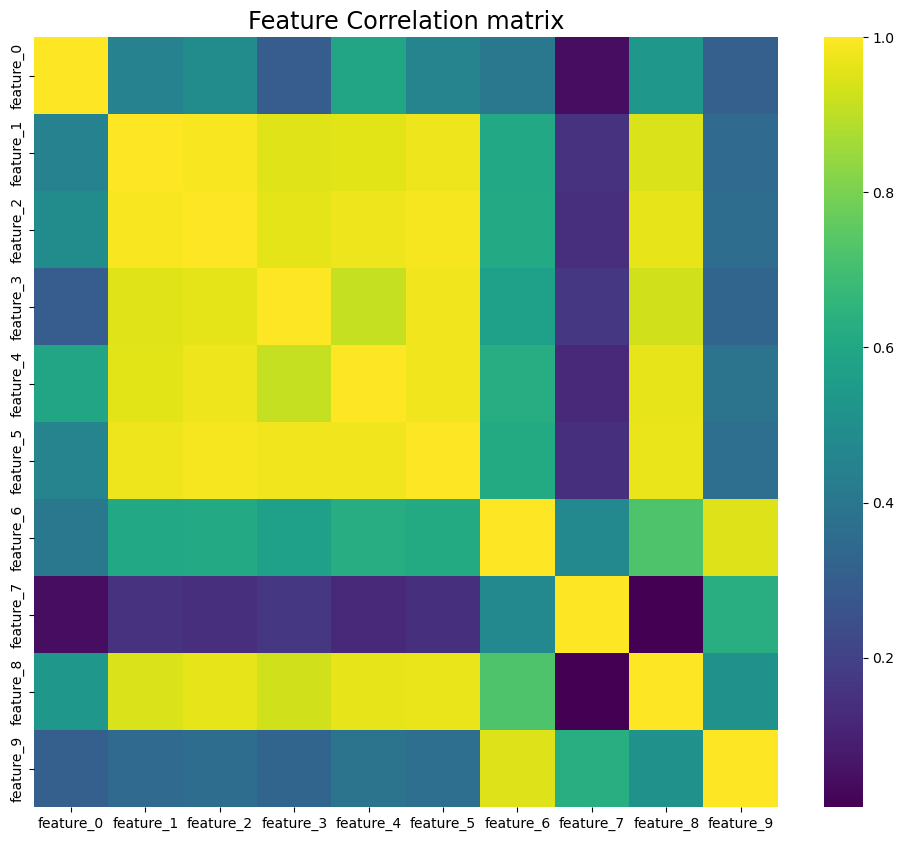

In [16]:
correlation_matrix = X_df.corr().abs()
# Visualizziamo la matrice di correlazione per avere un'idea
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='viridis')
#plt.xticks(fontsize=12)
#plt.yticks(fontsize=12)
plt.title('Feature Correlation matrix', fontsize='xx-large')
plt.show()

### Implement a selection Threshold
### We need to implement a criteria to select a subset of features relavant to the target variable and uncorrelated (or weakly correlated). 
### We thus define a threshold and all the features with a correlation score above it will be consider redundant.

In [17]:
correlation_threshold = 0.7
selected_features = []
# order features by relevance
sorted_features_by_relevance = relevance_scores['feature'].tolist()
for current_feature in sorted_features_by_relevance:
    is_redundant = False
    if not selected_features:
        #first feature = most relevant
        selected_features.append(current_feature)
    else:
        # for subsequent features, the correlation score will be checked
        for selected_feature in selected_features:
            corr_value = correlation_matrix.loc[current_feature, selected_feature]
            if corr_value >= correlation_threshold:
                is_redundant = True
                break  
        if not is_redundant:
            selected_features.append(current_feature)

print("--- Result ---")
print(f"Correlation Threshold: {correlation_threshold}")
print(f"N. Initial Features: {X_df.shape[1]}")
print(f"N. Selected Features: {len(selected_features)}")
print(f"Selected Features: {selected_features}")


--- Result ---
Correlation Threshold: 0.7
N. Initial Features: 10
N. Selected Features: 4
Selected Features: ['feature_3', 'feature_7', 'feature_9', 'feature_0']
